Title: cluster_plt.ipynb

Purpose: Make a nice plot of the clusters

Author: Onno Nennecke on 15.06.2025 Modified: 21.07.2025

Input data: 

- centroids and labels
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc.npz'
    - These files lie here: /home/onennecke/psl_clustering/clustering_results_nbc_2.npz
- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'
- PSL Data
    - This file lies here: /climca/people/onennecke/model_output/psl_anomaly/not_bc/

Output data:

- Cluster Plot: cluster_analysis_combined, cluster_analysis_combined_v2
    - This file lies here: /home/onennecke/Code/Figures/

In [1]:
# Load libraries
import os
import glob
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4, ll = True, bl = True, label_size = 14):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

### Read PSL data

In [3]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 1GB
Dimensions:   (ESM_run: 100, time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'r9i1p1f2'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p...
Data variables:
    psl       (ESM_run, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1820, 40, 50), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

In [4]:
lon_edges_1 = ts_datasets.lon.values
lat_edges_1 = ts_datasets.lat.values

def setup_gridlines_big(ax, deg = 20, alpha = 0.4, ll = True, bl = True, label_size = 18):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.array([-20, 0, 20, 40]) # np.array([340, 360, 0, 20, 40]) # np.arange(lon_edges_1.min(), lon_edges_1.max() + deg, deg)
    yticks = np.arange(lat_edges_1.min() + 1, lat_edges_1.max() + deg, deg)
    # ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    # ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=18)

In [5]:
# Load composites
path = '/climca/people/onennecke/model_output/composites/'
tas_composites = xr.open_dataset(path + 'tas_anomaly_composites.nc')
tas_composites.load()

wind_composites = xr.open_dataset(path + 'wind_anomaly_composites.nc')
wind_composites.load()

rsds_composites = xr.open_dataset(path + 'rsds_anomaly_composites.nc')
rsds_composites.load()

<xarray.Dataset> Size: 2kB
Dimensions:   (cluster: 5, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * cluster   (cluster) int32 20B 0 1 2 3 4
Data variables:
    rsds      (cluster, lat, lon) float32 2kB -5.105 -5.675 ... 10.24 9.734

In [6]:
lon_edges = tas_composites.lon.values
lat_edges = tas_composites.lat.values

def setup_gridlines_small(ax, deg = 2, alpha = 0.4, ll = True, bl = True, label_size = 18):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    # ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    # ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=18)

### Read cluster data

In [7]:
data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
labels = data['labels']
centroids_reshaped = data['centroids_reshaped']

In [8]:
# 1) Unpack sizes & coords
times   = ts_datasets.time           # (1820,)
runs    = ts_datasets.ESM_run        # (11,)
# print(times.shape, runs.shape)

# 2) Reshape labels → (time, ESM_run)
labels_da = xr.DataArray(
    labels.reshape(len(runs), len(times)),
    dims    = ("ESM_run", "time"),
    coords  = {"ESM_run": runs, "time": times},
    name    = "cluster_id",
)
labels_da

<xarray.DataArray 'cluster_id' (ESM_run: 100, time: 1820)> Size: 728kB
array([[4, 4, 4, ..., 1, 1, 1],
       [3, 3, 3, ..., 2, 2, 2],
       [2, 0, 0, ..., 0, 1, 1],
       ...,
       [4, 4, 4, ..., 0, 0, 0],
       [3, 3, 0, ..., 4, 4, 4],
       [2, 2, 2, ..., 2, 2, 3]], dtype=int32)
Coordinates:
  * ESM_run  (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p1f2'
  * time     (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31

### Only cluster center maps

/tmp/ipykernel_4109745/587697864.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


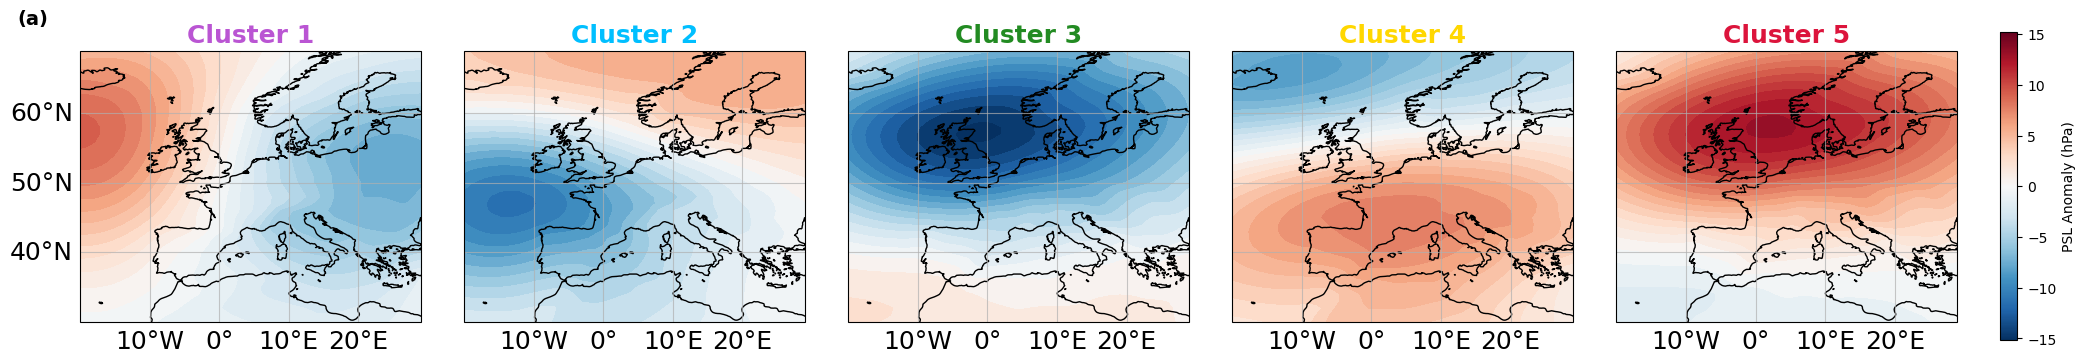

In [9]:
# Define cluster title colors (match figure)
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]

# 1) Compute the global vmin/vmax over all clusters (in hPa)
vmin = np.nanmin(centroids_reshaped / 100.0)
vmax = -vmin # np.nanmax(centroids_reshaped / 100.0)

# 2) Decide on subplot grid
ncols = 5
nrows = 1

# 3) Create figure + GridSpec (extra col for colorbar)
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.15)

lons = ((ts_datasets['lon'].values + 180) % 360) - 180
lats = ts_datasets['lat'].values

for i in range(5):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())

    # Plot with red-blue color scheme
    cf = ax.contourf(
        lons, lats, (centroids_reshaped[i, :, :] / 100.0),
        levels=20, vmin=vmin, vmax=vmax,
        cmap="RdBu_r", transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()
    if i == 0:
        setup_gridlines_big(ax, deg=10, alpha=0.7)
    else:
        setup_gridlines_big(ax, deg=10, alpha=0.7, ll=False)

    ax.set_title(f"Cluster {i + 1}", fontsize=18, color=cluster_colors[i], fontweight='bold')

# 4) Add (a) label
fig.text(0.1, 0.9, "(a)", fontsize=14, fontweight='bold')

# 5) Create ScalarMappable for colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

# 6) Add vertical colorbar on the right
cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('PSL Anomaly (hPa)', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4109745/2488673817.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


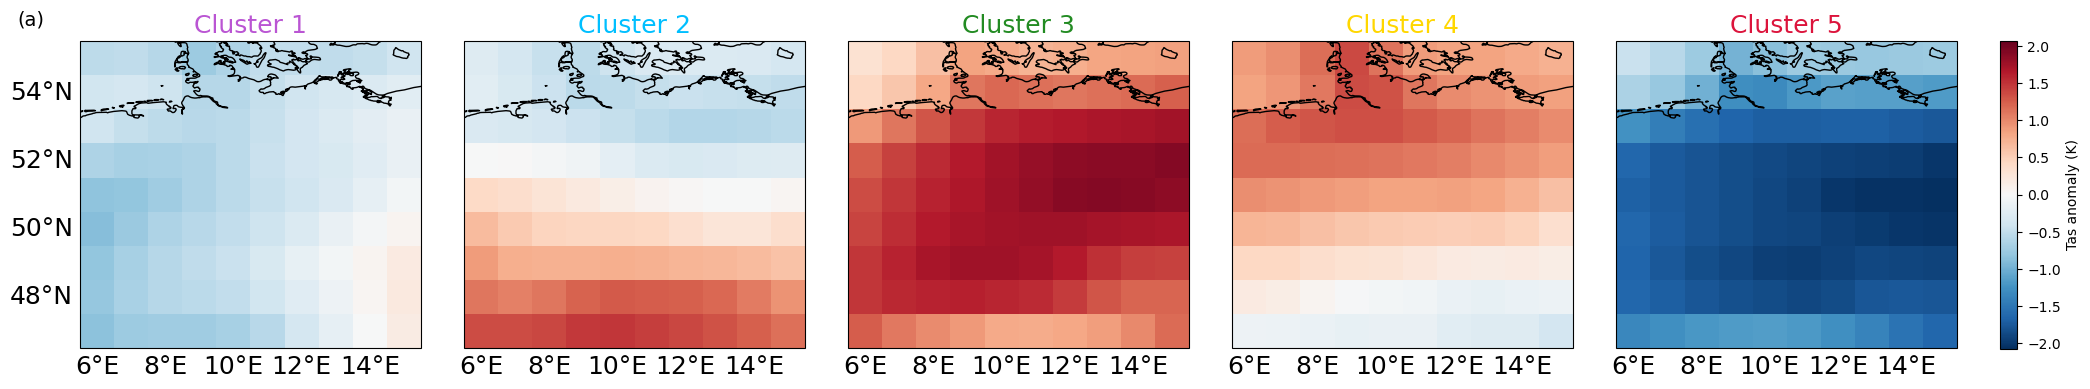

In [11]:

clusters_all = np.array(tas_composites['cluster'].values)

# Compute symmetric color limits (centered on zero)
# Use np.nanmin/np.nanmax on the values (convert to numpy; this is lazy for dask-backed arrays,
# you may want to .compute() beforehand if necessary).
vals = tas_composites['tas'].values
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)
# make symmetric about zero (like your example)
absmax = max(abs(vmin), abs(vmax))
vmin = -absmax
vmax = absmax

# Coordinates for contourf
lons = tas_composites['lon'].values
lats = tas_composites['lat'].values

# -------------------------
# Figure and GridSpec
# -------------------------

fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.05], wspace=0.15)

cmap_name = "RdBu_r"
cmap_used = None

for i, cl in enumerate(clusters_all):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())

    # select data for this cluster (2D lat x lon)
    da = tas_composites['tas'].sel(cluster=cl)

    # ensure the array ordering matches lats x lons
    # xarray will align automatically if we pass coords to pcolormesh
    cf = ax.pcolormesh(
        lons, lats, da.values,
        vmin=vmin, vmax=vmax,
        cmap=cmap_name, transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()
    # follow your pattern for gridlines (assumes setup_gridlines() exists)
    if i == 0:
        setup_gridlines_small(ax, deg=2, alpha=0)
    else:
        setup_gridlines_small(ax, deg=2, alpha=0, ll=False)

    # Title using provided cluster color list (cycle if fewer/more)
    color = cluster_colors[i % len(cluster_colors)]
    ax.set_title(f"Cluster {int(cl) + 1}", fontsize=18, color=color)

# Add (a) label like your example (position may be adjusted)
fig.text(0.1, 0.92, "(a)", fontsize=14)

# Shared vertical colorbar (use last col in GridSpec)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('Tas anomaly (K)', fontsize=10)  # replace 'units' with actual units (e.g. m/s)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


/tmp/ipykernel_4109745/923017449.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


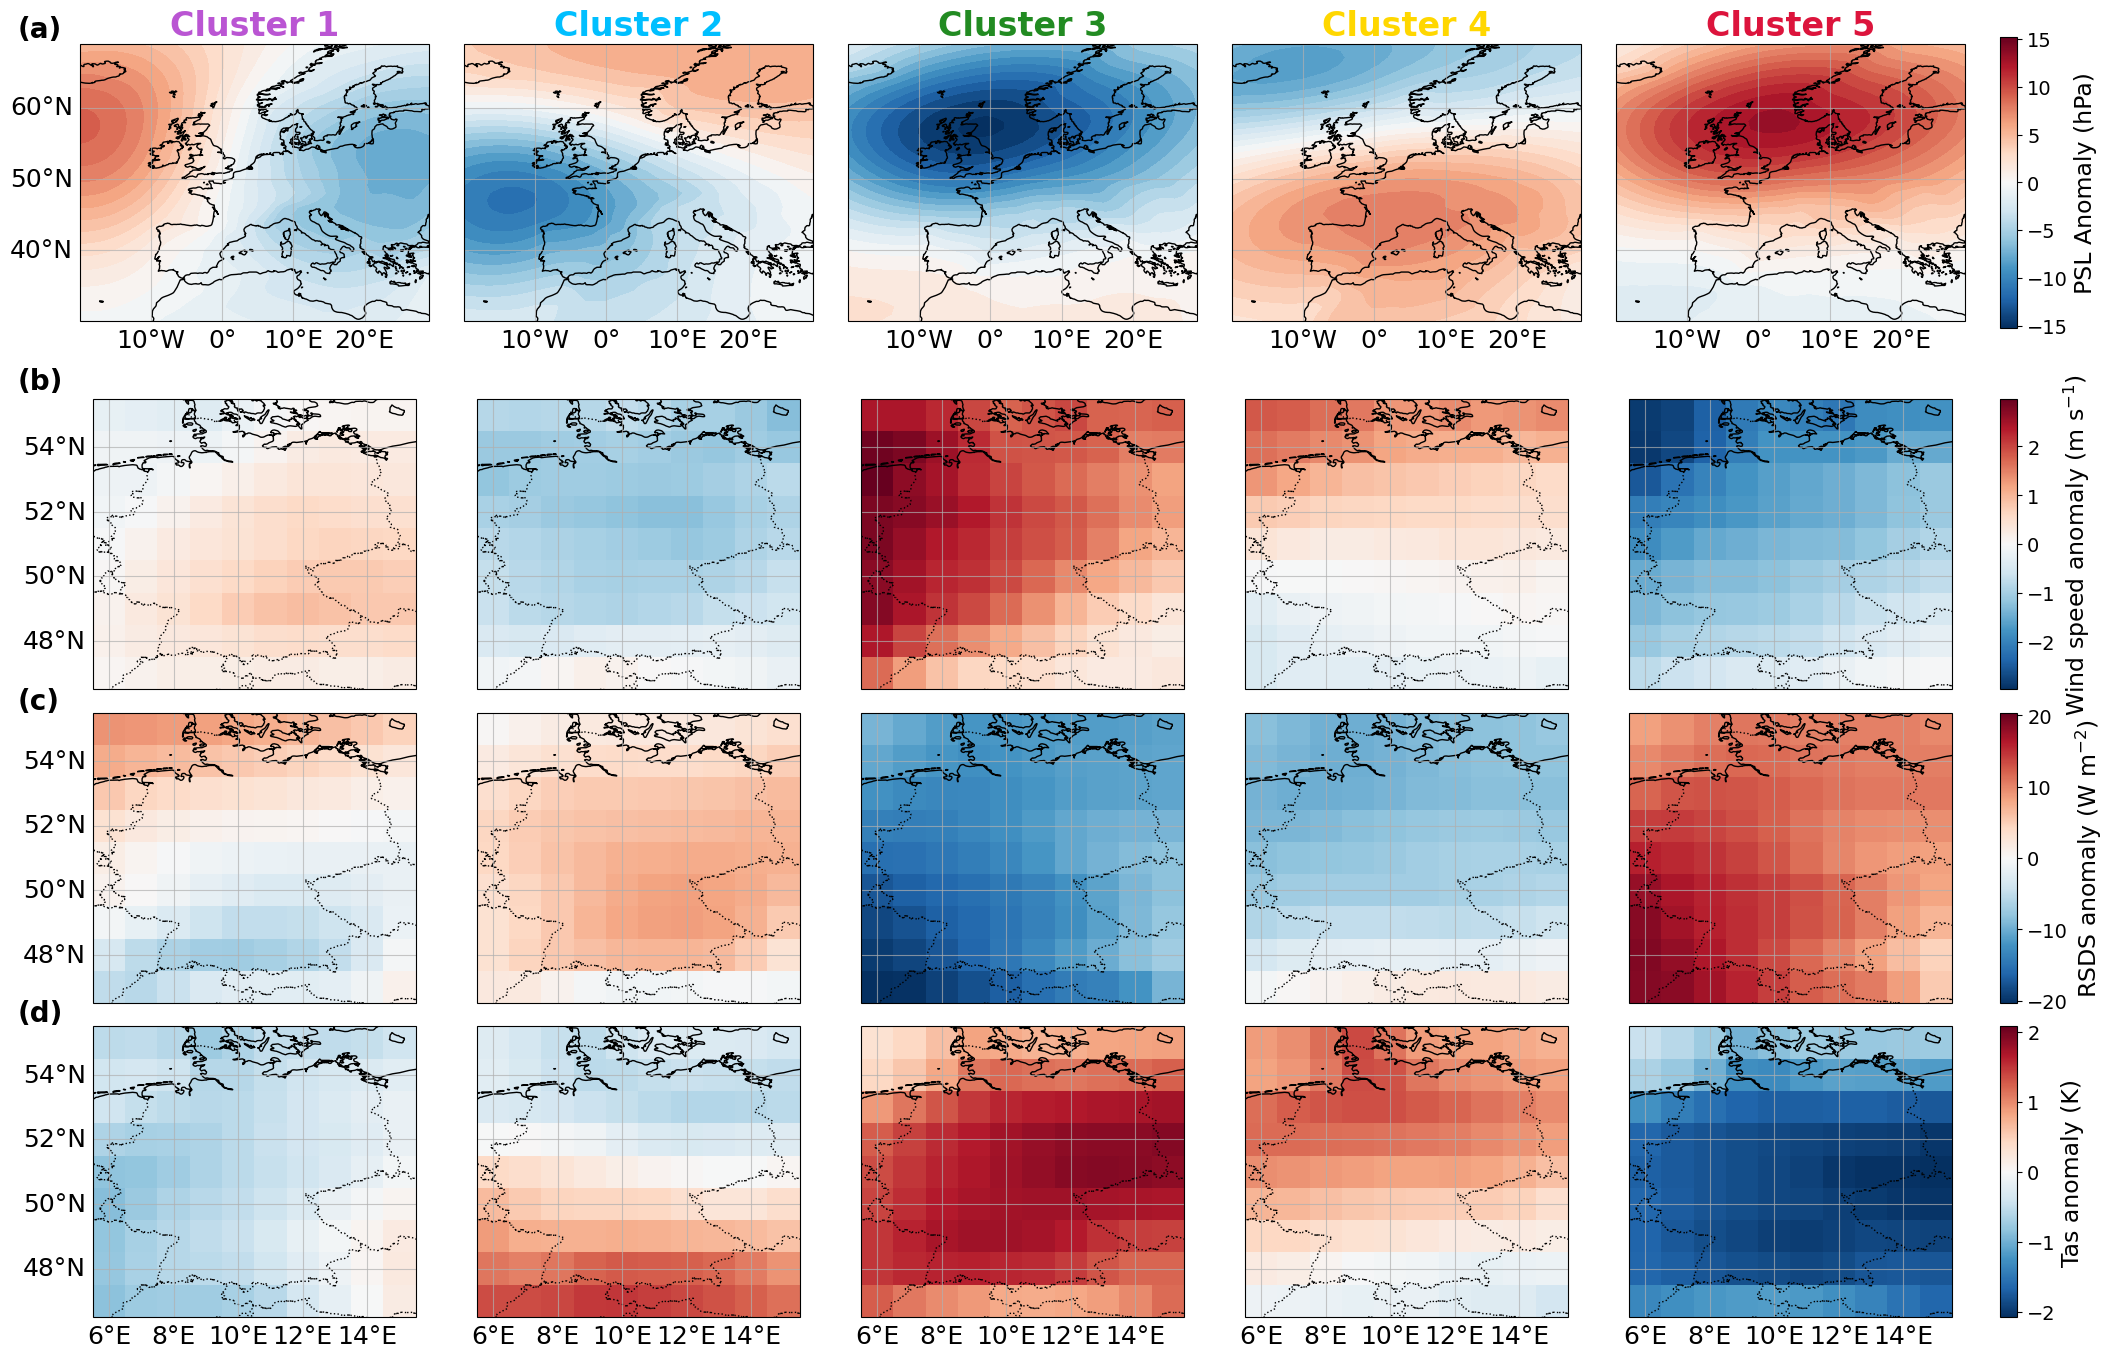

In [ ]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

# keep your cluster colors
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]

# layout
ncols = 5
nrows = 4  # psl, tas, sfcWind, rsds
fig = plt.figure(figsize=(5 * ncols, 4 * nrows))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.05], wspace=0.12, hspace=0.08)

# cluster ids/order (same as you used for tas)
clusters_all = np.array(tas_composites['cluster'].values)

# --- Coordinates ---
# PSL coords (your original lon wrapping)
lons_psl = ((ts_datasets['lon'].values + 180) % 360) - 180
lats_psl = ts_datasets['lat'].values

# tas coords
lons_tas = tas_composites['lon'].values
lats_tas = tas_composites['lat'].values

# sfcWind coords (assumed same structure; adjust if different)
lons_wind = wind_composites['lon'].values
lats_wind = wind_composites['lat'].values

# rsds coords
lons_rsds = rsds_composites['lon'].values
lats_rsds = rsds_composites['lat'].values

# --- color limits per row (symmetric about zero for anomalies as in your tas code) ---
# PSL (centroids_reshaped is in Pa? you used /100 to get hPa)
psl_vals = centroids_reshaped / 100.0
vmin_psl = np.nanmin(psl_vals)
vmax_psl = -vmin_psl  # symmetric like your snippet

# TAS
vals_tas = tas_composites['tas'].values
absmax = max(abs(np.nanmin(vals_tas)), abs(np.nanmax(vals_tas)))
vmin_tas, vmax_tas = -absmax, absmax

# SFCWIND
vals_wind = wind_composites['sfcWind'].values
absmax_wind = max(abs(np.nanmin(vals_wind)), abs(np.nanmax(vals_wind)))
vmin_wind, vmax_wind = -absmax_wind, absmax_wind

# RSDS
vals_rsds = rsds_composites['rsds'].values
absmax_rsds = max(abs(np.nanmin(vals_rsds)), abs(np.nanmax(vals_rsds)))
vmin_rsds, vmax_rsds = -absmax_rsds, absmax_rsds

# Colormap choices (match your examples)
cmap_psl = "RdBu_r"
cmap_others = "RdBu_r"

# Loop rows x columns and plot appropriate variable
for row in range(nrows):
    for col in range(ncols):
        ax = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        # top row: PSL (contourf)
        if row == 0:
            data = psl_vals[col, :, :]   # shape (lat, lon) expected
            cf = ax.contourf(
                lons_psl, lats_psl, data,
                levels=20, vmin=vmin_psl, vmax=vmax_psl,
                cmap=cmap_psl, transform=ccrs.PlateCarree()
            )
            cmap_used = cf.cmap
            # cluster title only on top row (colored)
            ax.set_title(f"Cluster {col + 1}", fontsize=24,
                         color=cluster_colors[col % len(cluster_colors)], fontweight='bold')
            # gridlines style for PSL (your original)
            if col == 0:
                setup_gridlines_big(ax, deg=10, alpha=0.7)
            else:
                setup_gridlines_big(ax, deg=10, alpha=0.7, ll=False)

        # second row: TAS (pcolormesh)
        elif row == 3:
            cl = clusters_all[col]
            da = tas_composites['tas'].sel(cluster=cl)
            cf = ax.pcolormesh(
                lons_tas, lats_tas, da.values,
                vmin=vmin_tas, vmax=vmax_tas,
                cmap=cmap_others, transform=ccrs.PlateCarree(), shading='auto'
            )
            cmap_used = cf.cmap
            # gridlines for lower rows
            if col == 0:
                setup_gridlines_small(ax, deg=2, alpha=0.7)
            else:
                setup_gridlines_small(ax, deg=2, alpha=0.7, ll=False)

        # third row: sfcWind
        elif row == 1:
            cl = clusters_all[col]
            da = wind_composites['sfcWind'].sel(cluster=cl)
            cf = ax.pcolormesh(
                lons_wind, lats_wind, da.values,
                vmin=vmin_wind, vmax=vmax_wind,
                cmap=cmap_others, transform=ccrs.PlateCarree(), shading='auto'
            )
            cmap_used = cf.cmap
            if col == 0:
                setup_gridlines_small(ax, deg=2, alpha=0.7, bl=False)
            else:
                setup_gridlines_small(ax, deg=2, alpha=0.7, ll=False, bl=False)

        # fourth row: rsds
        elif row == 2:
            cl = clusters_all[col]
            da = rsds_composites['rsds'].sel(cluster=cl)
            cf = ax.pcolormesh(
                lons_rsds, lats_rsds, da.values,
                vmin=vmin_rsds, vmax=vmax_rsds,
                cmap=cmap_others, transform=ccrs.PlateCarree(), shading='auto'
            )
            cmap_used = cf.cmap
            if col == 0:
                setup_gridlines_small(ax, deg=2, alpha=0.7, bl=False)
            else:
                setup_gridlines_small(ax, deg=2, alpha=0.7, ll=False, bl=False)

        ax.coastlines()
        if row != 0:
            ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
        # remove titles on rows other than top (explicitly - nothing to do)
        # optionally add y-label on the first column to indicate variable name
        # if col == 0:
        #     if row == 0:
        #         pass  # already used title
        #     elif row == 1:
        #         ax.text(-0.12, 0.5, "Tas anomaly (K)", transform=ax.transAxes,
        #                 rotation=90, va='center', fontsize=11, fontweight='bold')
        #     elif row == 2:
        #         ax.text(-0.12, 0.5, "SfcWind (m s$^{-1}$)", transform=ax.transAxes,
        #                 rotation=90, va='center', fontsize=11, fontweight='bold')
        #     elif row == 3:
        #         ax.text(-0.12, 0.5, "RSDS (W m$^{-2}$)", transform=ax.transAxes,
        #                 rotation=90, va='center', fontsize=11, fontweight='bold')

    # end for col: add one vertical colorbar per row in the rightmost GridSpec column
    if row == 0:
        norm = plt.Normalize(vmin=vmin_psl, vmax=vmax_psl)
        sm = ScalarMappable(norm=norm, cmap=cmap_used)
        sm.set_array([])
        cax = fig.add_subplot(gs[row, -1])
        cbar = plt.colorbar(sm, cax=cax)
        cbar.set_label('PSL Anomaly (hPa)', fontsize=18)
    elif row == 3:
        norm = plt.Normalize(vmin=vmin_tas, vmax=vmax_tas)
        sm = ScalarMappable(norm=norm, cmap=cmap_used)
        sm.set_array([])
        cax = fig.add_subplot(gs[row, -1])
        cbar = plt.colorbar(sm, cax=cax)
        cbar.set_label('Tas anomaly (K)', fontsize=18)
    elif row == 1:
        norm = plt.Normalize(vmin=vmin_wind, vmax=vmax_wind)
        sm = ScalarMappable(norm=norm, cmap=cmap_used)
        sm.set_array([])
        cax = fig.add_subplot(gs[row, -1])
        cbar = plt.colorbar(sm, cax=cax)
        cbar.set_label('Wind speed anomaly (m s$^{-1}$)', fontsize=18)
    elif row == 2:
        norm = plt.Normalize(vmin=vmin_rsds, vmax=vmax_rsds)
        sm = ScalarMappable(norm=norm, cmap=cmap_used)
        sm.set_array([])
        cax = fig.add_subplot(gs[row, -1])
        cbar = plt.colorbar(sm, cax=cax)
        cbar.set_label('RSDS anomaly (W m$^{-2}$)', fontsize=18)

# optional row labels (a)-(d) near left margin for the panel groups
fig.text(0.1, 0.88, "(a)", fontsize=20, fontweight='bold')  # PSL row
fig.text(0.1, 0.66, "(b)", fontsize=20, fontweight='bold')  # Tas row
fig.text(0.1, 0.46, "(c)", fontsize=20, fontweight='bold')  # Wind row
fig.text(0.1, 0.265, "(d)", fontsize=20, fontweight='bold')  # RSDS row

plt.tight_layout(rect=[0, 0, 1, 0.96])

# add extra vertical gap only below the first row
dy = 0.03  # how much to lower rows 1.. (increase/decrease to taste)
for ax in fig.axes:
    ss = ax.get_subplotspec()
    # only shift rows > 0
    if ss.rowspan.start > 0:
        pos = ax.get_position()
        ax.set_position([pos.x0, pos.y0 - dy, pos.width, pos.height])

# Save the plot
fig.savefig('/home/onennecke/Code/Figures/cluster_composite_anomalies_allvars.png', dpi=300, bbox_inches='tight')


plt.show()
